# Comparações Não e Sim

In [1]:
from analise_sinal import analiseEspectral

## Análise do sinal

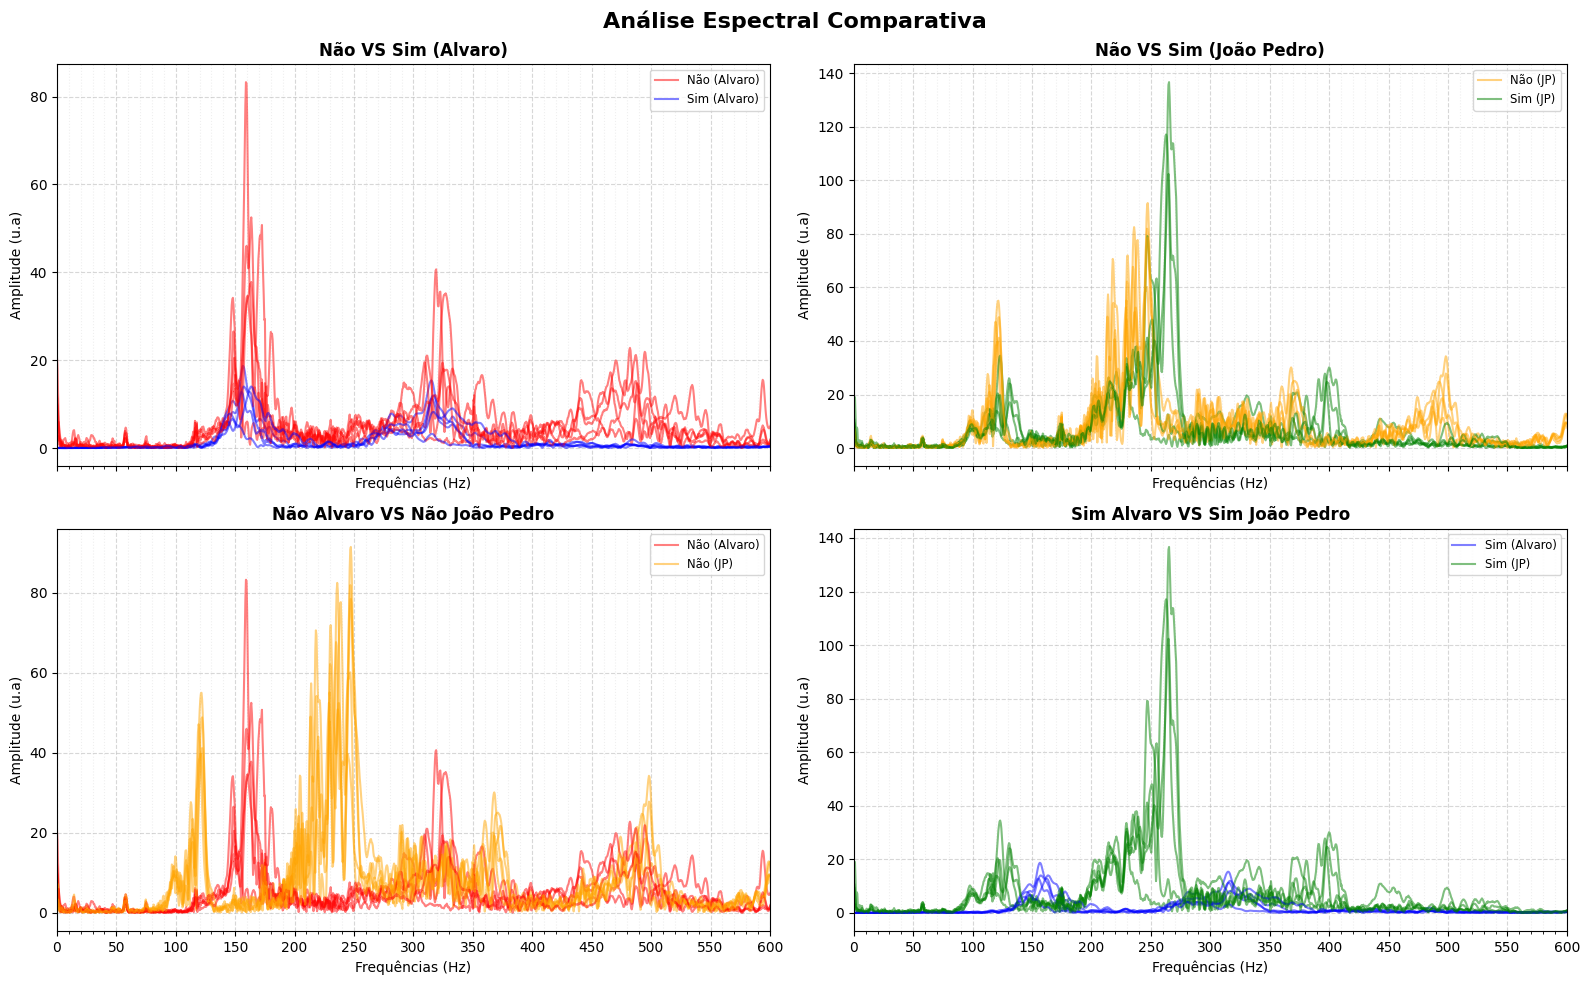

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parâmetros
diretorioArquivo = "audios_cortados"
frequenciadeCorte = 600
amostras = 10

fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for i in range(1, 6):
    try:
        nome_nao = f"nao_alv_{i}.m4a"
        f_n, amp_n = analiseEspectral.analiseporFourier(diretorioArquivo, nome_nao)
        
        nome_sim = f"sim_alv_{i}.m4a"
        f_s, amp_s = analiseEspectral.analiseporFourier(diretorioArquivo, nome_sim)
        
        jp_nao = f"nao_jp_{i}.m4a"
        f_n_jp, amp_n_jp = analiseEspectral.analiseporFourier(diretorioArquivo, jp_nao)
        
        jp_sim = f"sim_jp_{i}.m4a"
        f_s_jp, amp_s_jp = analiseEspectral.analiseporFourier(diretorioArquivo, jp_sim)
        
        # --- Plotagem nos Subplots Específicos ---
        lbl_cond = (i == 1) 

        # 1. Linha 0, Coluna 0: Não Vs Sim de Alvaro
        axs[0, 0].plot(f_n, amp_n, color='red', alpha=0.5, label="Não (Alvaro)" if lbl_cond else "")
        axs[0, 0].plot(f_s, amp_s, color='blue', alpha=0.5, label="Sim (Alvaro)" if lbl_cond else "")

        # 2. Linha 0, Coluna 1: Não vs Sim Joao Pedro
        axs[0, 1].plot(f_n_jp, amp_n_jp, color='orange', alpha=0.5, label="Não (JP)" if lbl_cond else "")
        axs[0, 1].plot(f_s_jp, amp_s_jp, color='green', alpha=0.5, label="Sim (JP)" if lbl_cond else "")

        # 3. Linha 1, Coluna 0: Nao alvaro Vs Nao Joao Pedro
        axs[1, 0].plot(f_n, amp_n, color='red', alpha=0.5, label="Não (Alvaro)" if lbl_cond else "")
        axs[1, 0].plot(f_n_jp, amp_n_jp, color='orange', alpha=0.5, label="Não (JP)" if lbl_cond else "")

        # 4. Linha 1, Coluna 1: Sim alvaro Vs Sim Joao Pedro
        axs[1, 1].plot(f_s, amp_s, color='blue', alpha=0.5, label="Sim (Alvaro)" if lbl_cond else "")
        axs[1, 1].plot(f_s_jp, amp_s_jp, color='green', alpha=0.5, label="Sim (JP)" if lbl_cond else "")

    except Exception as e:
        print(f"Erro no índice {i}: {e}")


titulos = [
    ["Não VS Sim (Alvaro)", "Não VS Sim (João Pedro)"],
    ["Não Alvaro VS Não João Pedro", "Sim Alvaro VS Sim João Pedro"]
]


for row in range(2):
    for col in range(2):
        ax = axs[row, col]
        
        # 1. Ajustado para começar do 0 Hz até o limite de corte
        ax.set_xlim(0, frequenciadeCorte)
        
        # 2. Define os marcadores principais de 50 em 50 Hz (inteiros e legíveis)
        ax.set_xticks(np.arange(0, frequenciadeCorte + 1, 50))
        
        # 3. Opcional: adiciona pequenos tracinhos de 10 em 10 Hz sem poluir com texto
        ax.set_xticks(np.arange(0, frequenciadeCorte + 1, 10), minor=True)
        
        ax.set_title(titulos[row][col], fontsize=12, fontweight='bold')
        ax.set_xlabel("Frequências (Hz)")
        ax.set_ylabel("Amplitude (u.a)")
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.5) 
        ax.grid(True, which='minor', linestyle=':', alpha=0.2) # Grid suave para os valores menores

fig.suptitle("Análise Espectral Comparativa", fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

## Escolhendo as frequências com base no gráfico:
- Todas as frequências entre 100 e 500 (inteiras)

In [3]:
import numpy as np
import pandas as pd


frequencias_desejadas = np.arange(100, 500)


linhas = []


arquivos = [
    ("nao_alv", 0, 1, 1, 0),
    ("sim_alv", 1, 0, 1, 0),
    ("nao_jp",  0, 1, 0, 1),
    ("sim_jp",  1, 0, 0, 1)
]

for arquivo, sim_lbl, nao_lbl, alv_lbl, jp_lbl in arquivos:

    for i in range(1, 6):

        try:

            nome_arquivo = f"{arquivo}_{i}.m4a"

            # FFT
            frequencias, amplitudes = analiseEspectral.analiseporFourier(
                diretorioArquivo,
                nome_arquivo
            )

            frequencias = np.array(frequencias)
            amplitudes = np.array(amplitudes)

            linha = {}

            # Frequências reais da FFT
            for f in frequencias_desejadas:

                # índice do bin REAL mais próximo
                idx = np.argmin(np.abs(frequencias - f))

                # salva amplitude REAL
                linha[f"{f}Hz"] = amplitudes[idx]

            # Labels
            linha["sim"] = sim_lbl
            linha["nao"] = nao_lbl
            linha["alvaro"] = alv_lbl
            linha["jp"] = jp_lbl

            

            linhas.append(linha)

        except Exception as e:
            print(f"Erro em {nome_arquivo}: {e}")

# Cria DataFrame
df = pd.DataFrame(linhas)

In [4]:
df.to_csv("dados.csv", index = False)

## Normalizando as amplitudes

$$
\bar{x}_i(j)=
\frac{x_i(j)-x_{i,\min}}
{x_{i,\max}-x_{i,\min}}
$$

In [5]:
# Embaralhando os dados
df_embaralhado = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separando a tabela
X = df_embaralhado.iloc[:, :-4]

y = df_embaralhado.iloc[:, -4:]

In [6]:
# Normalizando
X_normalizado = (X - X.min()) / (X.max() - X.min())

In [7]:
df_normalizado = pd.concat([X_normalizado, y], axis=1)
df_normalizado.to_csv("dataset.csv", index=False)

## Tabela final

In [8]:
df_normalizado

,100Hz,101Hz,102Hz,103Hz,104Hz,105Hz,106Hz,107Hz,108Hz,109Hz,...,494Hz,495Hz,496Hz,497Hz,498Hz,499Hz,sim,nao,alvaro,jp
0,0.042688,0.047043,0.040929,0.026008,0.060621,0.004700,0.019363,0.027420,0.031852,0.060081,...,0.203709,0.226545,0.205272,0.140049,0.085072,0.068905,0,1,1,0
1,0.541976,0.639160,0.590463,0.433431,0.424072,0.451968,0.468724,0.428988,0.283641,0.367342,...,0.137889,0.195334,0.248867,0.264670,0.261320,0.290036,1,0,0,1
2,0.661268,0.863054,0.808278,0.648375,0.571323,0.660701,0.743379,0.750416,0.635785,0.880645,...,0.018359,0.012515,0.024651,0.038050,0.039885,0.033435,1,0,0,1
3,0.037613,0.026202,0.052462,0.024464,0.023228,0.034205,0.033227,0.039887,0.013059,0.014056,...,0.129519,0.122237,0.078817,0.084513,0.118805,0.152292,0,1,1,0
4,0.003079,0.009591,0.013833,0.016232,0.013473,0.011164,0.003815,0.002279,0.000000,0.001956,...,0.000431,0.000978,0.000000,0.000000,0.000000,0.000722,1,0,1,0
5,0.031570,0.045675,0.044942,0.043717,0.047033,0.052207,0.038454,0.022485,0.014665,0.022528,...,0.011620,0.008420,0.005082,0.004024,0.002245,0.000951,1,0,1,0
6,0.522006,0.862410,0.306990,0.461207,0.851105,0.779012,0.213882,1.000000,1.000000,1.000000,...,0.857118,0.793216,0.661805,0.512591,0.398920,0.359500,0,1,0,1
7,0.043960,0.046205,0.003366,0.046487,0.069385,0.042145,0.036023,0.060670,0.053014,0.081058,...,0.782258,0.808832,0.681463,0.548457,0.453781,0.366664,0,1,1,0
8,0.470952,0.641956,0.705097,0.669779,0.608305,0.616531,0.616860,0.507541,0.335992,0.372825,...,0.070733,0.095483,0.096260,0.079568,0.048915,0.019906,1,0,0,1
9,0.539426,0.692376,0.623021,0.482972,0.462363,0.509863,0.568360,0.467504,0.302403,0.364020,...,0.022957,0.035492,0.044468,0.048458,0.052668,0.058522,1,0,0,1


# Análise exploratória dos dados

In [9]:
import seaborn as sns

In [10]:
sns.set_theme(style="whitegrid")

dataset = pd.read_csv("dados.csv")

In [11]:
display(dataset.head())

,100Hz,101Hz,102Hz,103Hz,104Hz,105Hz,106Hz,107Hz,108Hz,109Hz,...,494Hz,495Hz,496Hz,497Hz,498Hz,499Hz,sim,nao,alvaro,jp
0,0.651361,0.523596,0.433085,0.284078,0.621918,0.097458,0.225768,0.317320,0.533097,0.819534,...,5.828865,6.310657,6.043999,4.652935,3.045436,2.280173,0,1,1,0
1,0.583792,0.312941,0.544783,0.268548,0.272264,0.333770,0.335087,0.441696,0.241848,0.206695,...,3.841216,3.556304,2.505863,2.897946,4.196789,4.982582,0,1,1,0
2,0.578108,0.121967,0.188687,0.617586,0.589332,0.215761,0.240138,0.372691,0.458449,0.294702,...,6.506271,8.204770,9.576093,10.100632,8.886520,5.688244,0,1,1,0
3,0.668303,0.515128,0.069257,0.490118,0.703867,0.397366,0.357137,0.649028,0.861056,1.098841,...,21.329036,21.686383,19.367534,17.559091,15.630041,11.929886,0,1,1,0
4,0.375238,0.479569,0.461391,0.157174,0.111233,0.229498,0.271648,0.238937,0.193086,0.582556,...,9.251597,10.852122,11.351408,11.360639,11.187716,10.294651,0,1,1,0


In [12]:
valores = dataset.iloc[:, :-4]

labels = dataset.iloc[:, -4:]

In [13]:
valores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Columns: 400 entries, 100Hz to 499Hz
dtypes: float64(400)
memory usage: 62.6 KB


In [14]:
describe_valores = valores.describe()
describe_valores.to_csv("describe.csv", index=False)

In [15]:
describe_valores

,100Hz,101Hz,102Hz,103Hz,104Hz,105Hz,106Hz,107Hz,108Hz,109Hz,...,490Hz,491Hz,492Hz,493Hz,494Hz,495Hz,496Hz,497Hz,498Hz,499Hz
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,4.541169,4.086497,3.456522,3.347239,3.203621,2.590684,2.186802,3.100669,4.030727,4.075206,...,5.740362,5.265238,5.819572,6.629235,7.400409,7.848738,8.050138,8.109653,7.680108,6.796321
std,4.488238,4.006419,3.471246,3.332485,3.202541,2.691372,2.368590,3.235089,4.688995,4.706689,...,6.352894,6.561546,7.254433,8.019311,8.468056,8.397561,8.445709,9.011157,9.438187,8.934984
min,0.082964,0.048102,0.036659,0.022417,0.055061,0.059812,0.073079,0.043770,0.039455,0.019528,...,0.448151,0.423000,0.391666,0.389329,0.371218,0.328553,0.300598,0.227237,0.141787,0.047129
25%,0.471307,0.284913,0.300780,0.280195,0.397637,0.226063,0.236546,0.260801,0.248665,0.313303,...,0.796427,0.691675,0.855103,1.168312,0.955471,0.974626,0.955277,1.214365,1.263991,0.690849
50%,3.511045,3.514042,1.777417,2.500358,2.237225,1.316251,1.067970,2.123586,2.606616,1.392084,...,2.207257,1.299397,1.887107,2.638185,3.953343,4.521406,4.518943,3.775440,3.621112,2.548662
75%,8.348256,7.257916,6.547334,6.548358,5.483842,4.844901,3.773180,5.055939,5.583338,5.876337,...,9.231174,8.988588,8.549808,8.456187,9.746589,11.707666,12.807579,12.008134,11.213612,10.606637
max,13.398180,10.155703,9.722282,10.083343,9.405862,8.069147,7.958514,10.020059,15.537269,13.334916,...,21.873012,23.378722,24.771557,25.169131,27.162670,26.734318,28.280011,31.828347,34.273367,32.454915


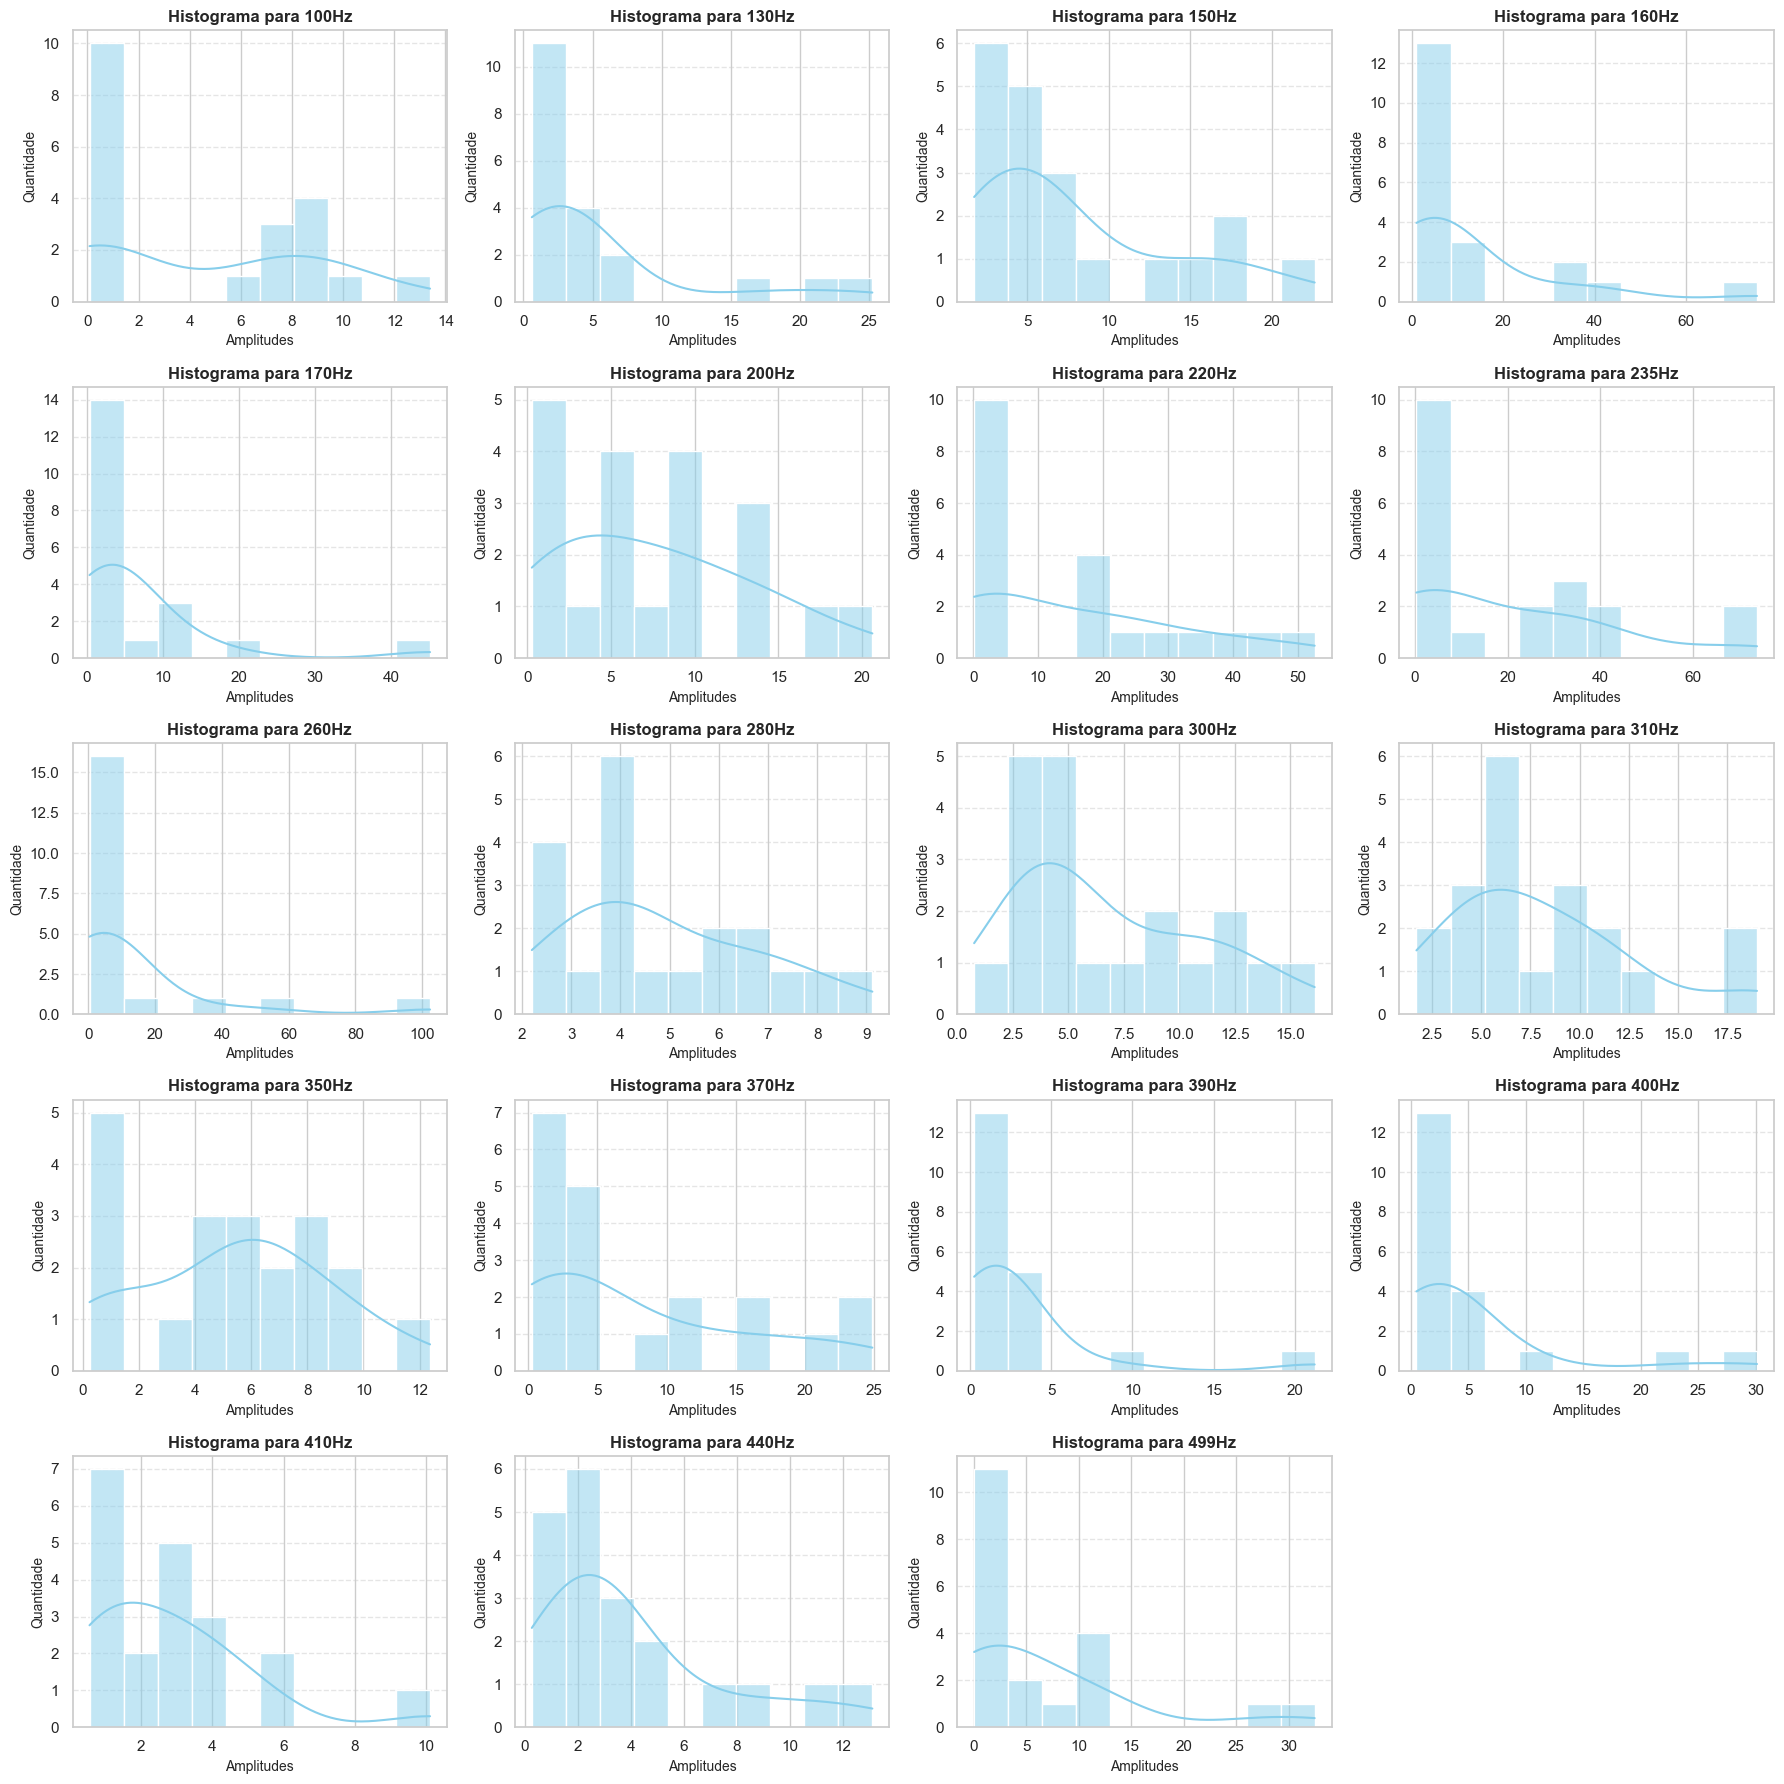

In [16]:
frequencias_foco = [
    '100Hz', '130Hz', '150Hz', '160Hz', '170Hz', 
    '200Hz', '220Hz', '235Hz', '260Hz', '280Hz', 
    '300Hz', '310Hz', '350Hz', '370Hz', '390Hz', 
    '400Hz', '410Hz', '440Hz', '499Hz'
]

# 3. Ajustado para 5 linhas e 4 colunas para acomodar os 19 gráficos de forma organizada
nrows = 5
ncols = 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 18))

# Achatar a matriz de eixos para facilitar o loop por índice
axes = axes.flatten()

# 4. Loop para plotar cada histograma
for i, freq in enumerate(frequencias_foco):
    sns.histplot(df[freq], kde=True, color='skyblue', bins=10, ax=axes[i])
    
    # Customizações visuais
    axes[i].set_title(f'Histograma para {freq}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Amplitudes', fontsize=10)
    axes[i].set_ylabel('Quantidade', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# 5. Deleta o último quadrante (posição 20) que ficou vazio, já que temos 19 gráficos
for j in range(len(frequencias_foco), len(axes)):
    fig.delaxes(axes[j])

# 6. Ajustar o espaçamento automático e exibir
plt.tight_layout()
plt.show()

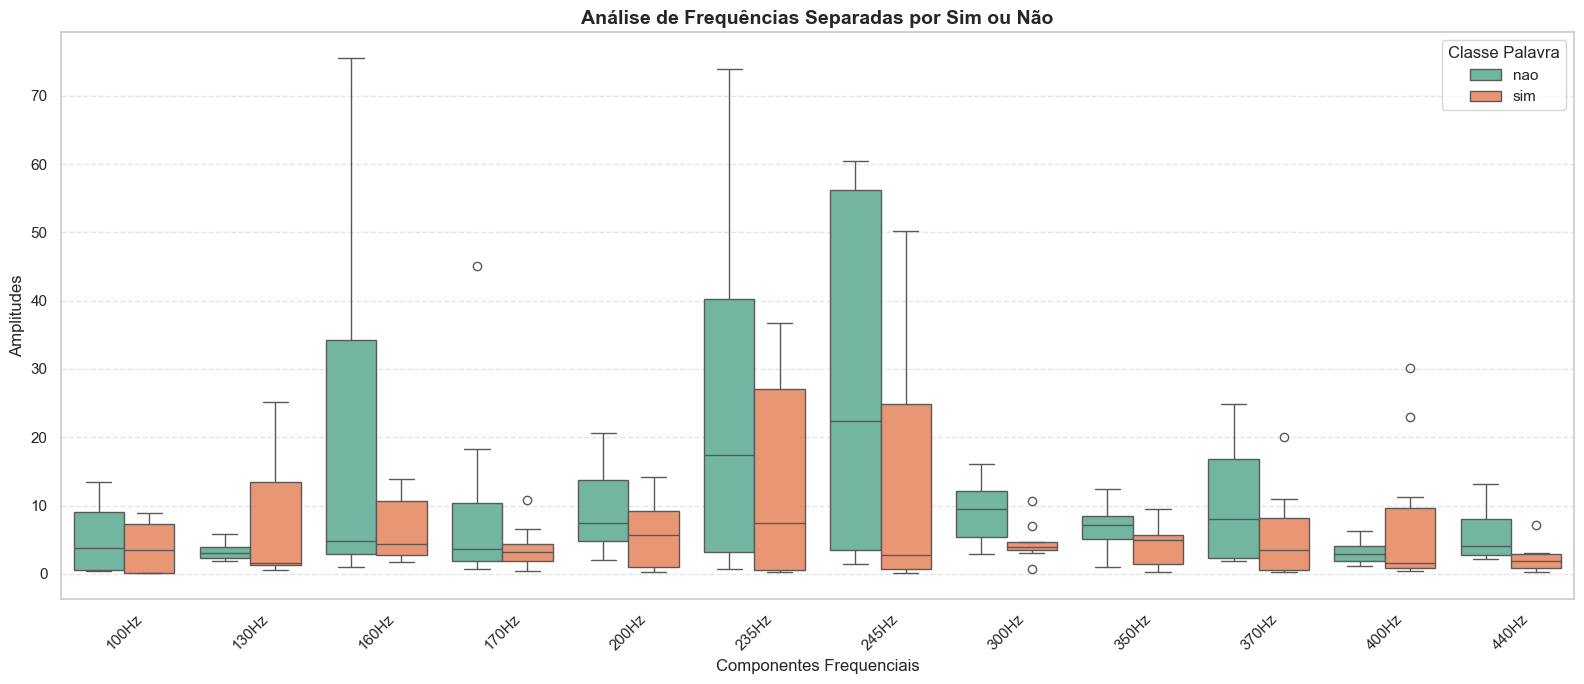

In [17]:
# 1. Definir as frequências de foco
frequencias_foco = [
    '100Hz', '130Hz', '160Hz', '170Hz', 
    '200Hz', '235Hz', '245Hz', '300Hz', 
    '350Hz', '370Hz', '400Hz', '440Hz'
]

# 2. Reorganizar os dados para o formato "longo"
df_long = pd.melt(dataset, id_vars=['sim'], value_vars=frequencias_foco, 
                  var_name='Frequencia', value_name='Amplitude')

# --- O PULO DO GATO ESTÁ AQUI ---
# Substitui 0 por 'nao' e 1 por 'sim' na coluna que define a legenda
df_long['sim'] = df_long['sim'].map({0: 'nao', 1: 'sim'})

# 3. Configurar o gráfico
plt.figure(figsize=(16, 7))

# 4. Plotar o boxplot agrupando pelo "hue" (que agora contém as strings 'nao' e 'sim')
sns.boxplot(data=df_long, x='Frequencia', y='Amplitude', hue='sim', palette='Set2')

# 5. Customização
plt.title('Análise de Frequências Separadas por Sim ou Não', fontsize=14, fontweight='bold')
plt.xlabel('Componentes Frequenciais', fontsize=12)
plt.ylabel('Amplitudes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# A legenda vai puxar automaticamente os textos novos com o seu título personalizado
plt.legend(title='Classe Palavra')

plt.tight_layout()
plt.show()

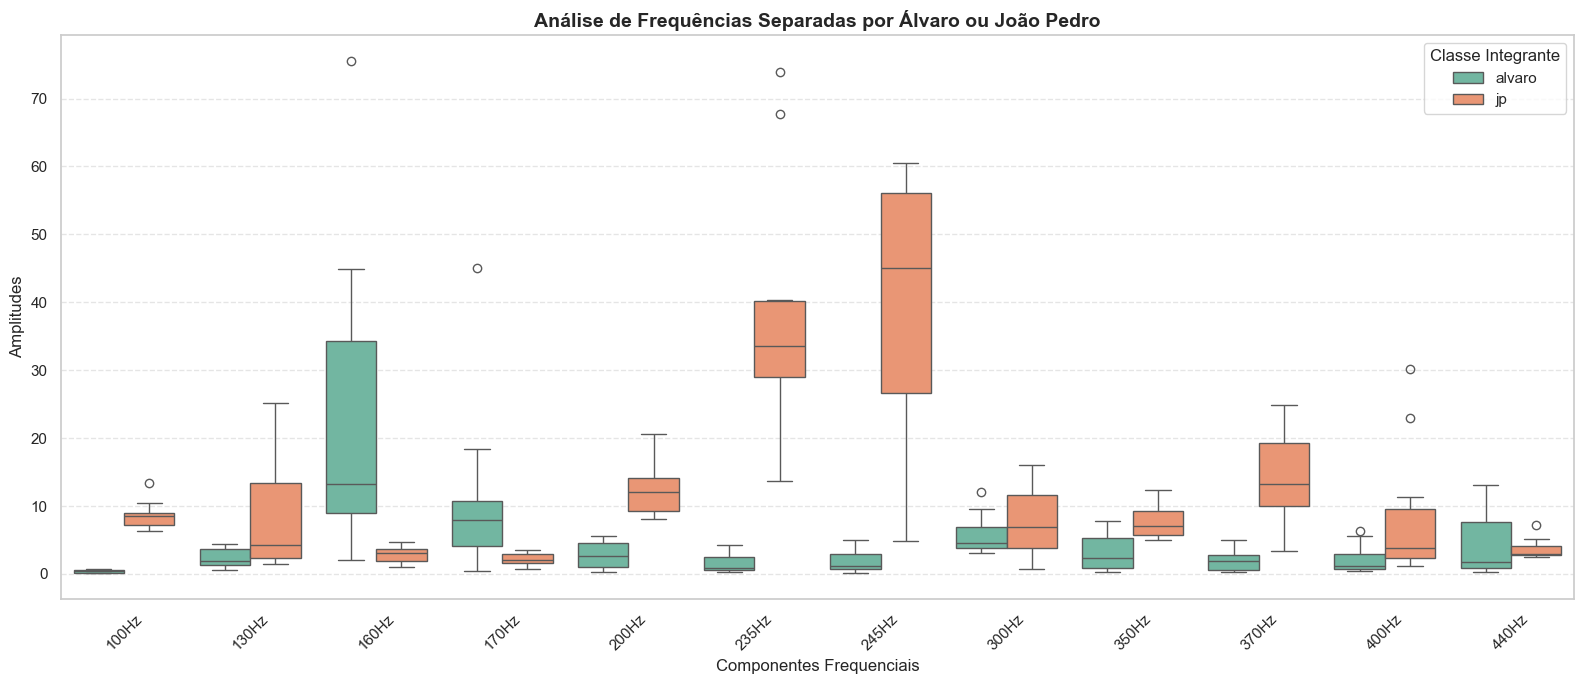

In [18]:
frequencias_foco = [
    '100Hz', '130Hz', '160Hz', '170Hz', 
    '200Hz', '235Hz', '245Hz', '300Hz', 
    '350Hz', '370Hz', '400Hz', '440Hz'
]

# 2. Reorganizar os dados para o formato "longo" que o Seaborn exige para agrupamentos
df_long = pd.melt(dataset, id_vars=['alvaro'], value_vars=frequencias_foco, 
                  var_name='Frequencia', value_name='Amplitude')
df_long['alvaro'] = df_long['alvaro'].map({0: 'jp', 1: 'alvaro'})
# 3. Configurar o gráfico
plt.figure(figsize=(16, 7))

# 4. Plotar o boxplot agrupando pelo "hue" (a coluna 'sim')
sns.boxplot(data=df_long, x='Frequencia', y='Amplitude', hue='alvaro', palette='Set2')

# 5. Customização
plt.title('Análise de Frequências Separadas por Álvaro ou João Pedro', fontsize=14, fontweight='bold')
plt.xlabel('Componentes Frequenciais', fontsize=12)
plt.ylabel('Amplitudes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Classe Integrante')

plt.tight_layout()
plt.show()

# Treinamento da Rede

## Dataset

In [19]:
df_normalizado

,100Hz,101Hz,102Hz,103Hz,104Hz,105Hz,106Hz,107Hz,108Hz,109Hz,...,494Hz,495Hz,496Hz,497Hz,498Hz,499Hz,sim,nao,alvaro,jp
0,0.042688,0.047043,0.040929,0.026008,0.060621,0.004700,0.019363,0.027420,0.031852,0.060081,...,0.203709,0.226545,0.205272,0.140049,0.085072,0.068905,0,1,1,0
1,0.541976,0.639160,0.590463,0.433431,0.424072,0.451968,0.468724,0.428988,0.283641,0.367342,...,0.137889,0.195334,0.248867,0.264670,0.261320,0.290036,1,0,0,1
2,0.661268,0.863054,0.808278,0.648375,0.571323,0.660701,0.743379,0.750416,0.635785,0.880645,...,0.018359,0.012515,0.024651,0.038050,0.039885,0.033435,1,0,0,1
3,0.037613,0.026202,0.052462,0.024464,0.023228,0.034205,0.033227,0.039887,0.013059,0.014056,...,0.129519,0.122237,0.078817,0.084513,0.118805,0.152292,0,1,1,0
4,0.003079,0.009591,0.013833,0.016232,0.013473,0.011164,0.003815,0.002279,0.000000,0.001956,...,0.000431,0.000978,0.000000,0.000000,0.000000,0.000722,1,0,1,0
5,0.031570,0.045675,0.044942,0.043717,0.047033,0.052207,0.038454,0.022485,0.014665,0.022528,...,0.011620,0.008420,0.005082,0.004024,0.002245,0.000951,1,0,1,0
6,0.522006,0.862410,0.306990,0.461207,0.851105,0.779012,0.213882,1.000000,1.000000,1.000000,...,0.857118,0.793216,0.661805,0.512591,0.398920,0.359500,0,1,0,1
7,0.043960,0.046205,0.003366,0.046487,0.069385,0.042145,0.036023,0.060670,0.053014,0.081058,...,0.782258,0.808832,0.681463,0.548457,0.453781,0.366664,0,1,1,0
8,0.470952,0.641956,0.705097,0.669779,0.608305,0.616531,0.616860,0.507541,0.335992,0.372825,...,0.070733,0.095483,0.096260,0.079568,0.048915,0.019906,1,0,0,1
9,0.539426,0.692376,0.623021,0.482972,0.462363,0.509863,0.568360,0.467504,0.302403,0.364020,...,0.022957,0.035492,0.044468,0.048458,0.052668,0.058522,1,0,0,1


### Separando as features 

In [20]:
X = df_normalizado.drop(columns=['sim', 'nao', 'alvaro','jp']).values
y = df_normalizado[['sim', 'nao', 'alvaro','jp']].values

### Modelo

In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold

In [22]:
k_folds = 5
objetoKfold = KFold(n_splits=k_folds, shuffle=True, random_state=67)


In [23]:
acuraciaFolds = []

In [24]:
from sklearn.metrics import accuracy_score, classification_report

In [25]:
from sklearn.metrics import roc_curve, auc

In [26]:
label_names = ['sim', 'nao', 'alvaro', 'jp']
oof_preds = np.zeros_like(y, dtype=float)

In [27]:
for fold, (j, k) in enumerate(objetoKfold.split(X, y)):

    X_train_fold, X_test_fold = X[j], X[k]
    y_train_fold, y_test_fold = y[j], y[k]

    mlp = MLPClassifier(
    hidden_layer_sizes= (6, 7),
    max_iter=2000,
    tol=1e-3,
    learning_rate_init=0.001,
    activation='relu',
    learning_rate='constant',
    verbose=False
    )

    # Treinamento
    mlp.fit(X_train_fold, y_train_fold)

    oof_preds[k] = mlp.predict_proba(X_test_fold)
    
    # Predição
    y_pred = mlp.predict(X_test_fold)
    
    
    acc = accuracy_score(y_test_fold, y_pred)
    acuraciaFolds.append(acc)
    
    #print(f"Acurácia da Dobra {fold + 1}: {acc:.4f}\n")
    
print("--- Resultado Final ---")
print(f"Acurácias por fold: {[round(a, 4) for a in acuraciaFolds]}")
print(f"Média de Acurácia: {np.mean(acuraciaFolds):.4f}")
print(f"Desvio Padrão: {np.std(acuraciaFolds):.4f}")


--- Resultado Final ---
Acurácias por fold: [0.5, 1.0, 1.0, 1.0, 0.75]
Média de Acurácia: 0.8500
Desvio Padrão: 0.2000


In [28]:
from sklearn.model_selection import train_test_split

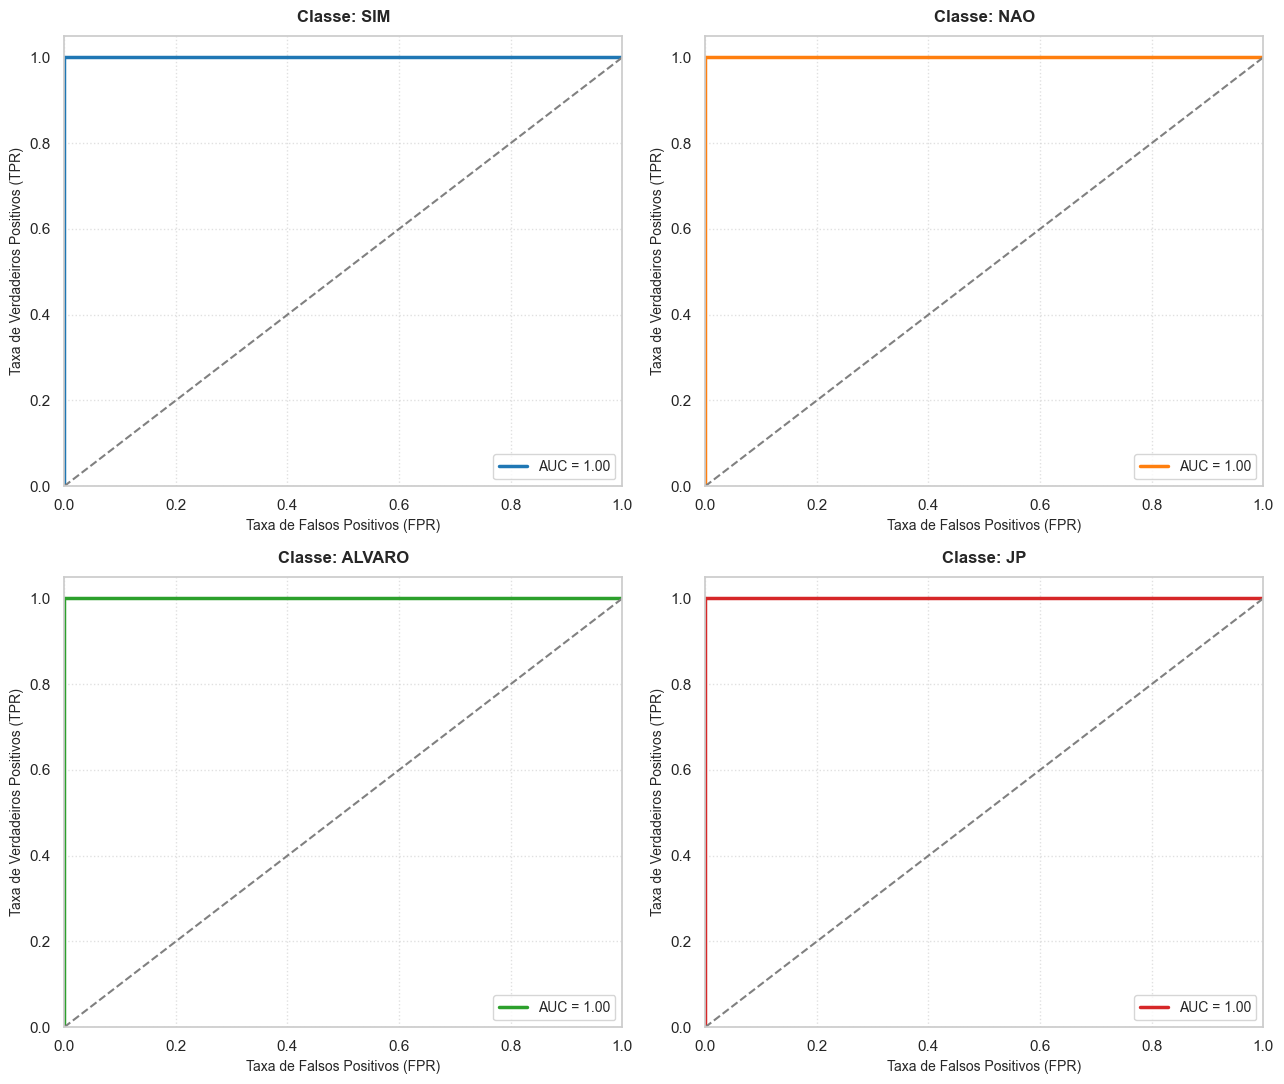

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)

rna = MLPClassifier(
    hidden_layer_sizes= (3, 3),
    max_iter=2000,
    tol=1e-3,
    learning_rate_init=0.001,
    activation='relu',
    learning_rate='constant',
    verbose=False
)

# Treinando o modelo com os 70% de treino
rna.fit(X_train, y_train)

# 4. Obtendo as probabilidades das predições nos 30% de teste
y_probs = rna.predict_proba(X_test)

# Nomes dos alvos para a legenda do gráfico
label_names = ['sim', 'nao', 'alvaro', 'jp']

cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Uma cor diferente para cada gráfico

# 5. Criando a estrutura de Subplots (Grade 2x2)
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten() # Transforma a matriz 2x2 em uma lista linear de 4 posições

for i, label in enumerate(label_names):
    # Calcula a curva ROC e o AUC específico da coluna 'i'
    fpr, tpr, _ = roc_curve(y_test[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Seleciona o eixo atual do subplot
    ax = axes[i]
    
    # Plota a curva ROC da respectiva classe
    ax.plot(fpr, tpr, color=cores[i], lw=2.5, label=f'AUC = {roc_auc:.2f}')
    
    # Linha diagonal cinza (referência de chute aleatório)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5)
    
    # Customizações de cada quadrante
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=10)
    ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=10)
    ax.set_title(f'Classe: {label.upper()}', fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc="lower right", fontsize=10, frameon=True)
    ax.grid(True, linestyle=':', alpha=0.6)

# Ajusta automaticamente o espaçamento para evitar sobreposição de textos
plt.tight_layout()
plt.show()

In [30]:
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

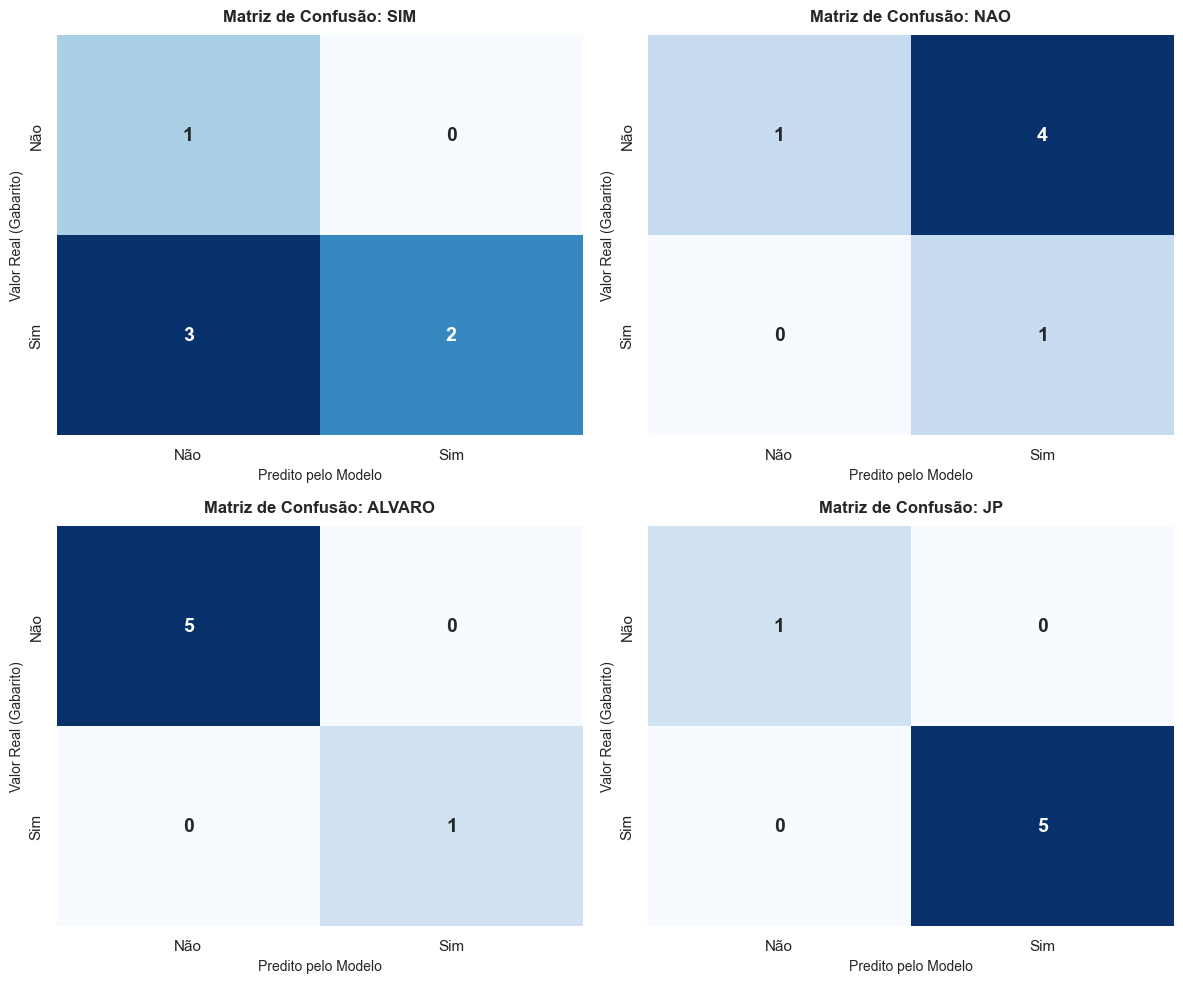

In [31]:
# 1. Gerar as predições binárias (0 ou 1) usando o modelo treinado
# (Certifique-se de rodar este bloco logo após o rna.fit(X_train, y_train))
y_pred = rna.predict(X_test)

# 2. Calcula as matrizes de confusão para todas as classes de uma vez
matrizes = multilabel_confusion_matrix(y_test, y_pred)

# Nomes das classes para os títulos
label_names = ['sim', 'nao', 'alvaro', 'jp']

# 3. Criando a estrutura de Subplots (Grade 2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, label in enumerate(label_names):
    ax = axes[i]
    
    # Plota a matriz de confusão da classe atual como um mapa de calor
    sns.heatmap(
        matrizes[i], 
        annot=True,          # Mostra os números dentro dos quadrados
        fmt='d',             # Exibe como números inteiros
        cmap='Blues',        # Tons de azul
        cbar=False,          # Remove a barra lateral de cores
        annot_kws={"size": 14, "weight": "bold"}, # Aumenta a fonte dos números
        ax=ax
    )
    
    # Configurações de rótulos e títulos para cada quadrante
    ax.set_title(f'Matriz de Confusão: {label.upper()}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predito pelo Modelo', fontsize=10)
    ax.set_ylabel('Valor Real (Gabarito)', fontsize=10)
    
    # Ajusta os nomes dos eixos (0 = Não pertence à classe, 1 = Pertence)
    ax.set_xticklabels(['Não', 'Sim'], fontsize=11)
    ax.set_yticklabels(['Não', 'Sim'], fontsize=11)

# Ajusta o espaçamento para não cortar nenhum texto
plt.tight_layout()
plt.show()